In [ ]:
# Cliff Walking - Comparacao entre Q-Learning Tabular e
# Aproximacao de Funcao com Semi-Gradiente TD
# Baseado no Exemplo 6.6 do Sutton & Barto
# Aqui a gente implementa tudo do zero, sem usar biblioteca de RL
# A ideia eh comparar o agente tabular com o agente que usa
# funcao linear pra aproximar Q(s,a)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# semente pra reprodutibilidade dos resultados
np.random.seed(42)

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


---
# 1. Implementacao do Ambiente Cliff Walking
---

In [ ]:
# 1(a) - Dinamica do ambiente: estados, acoes, recompensas e termino

# O gridworld tem 4 linhas e 12 colunas (48 estados no total)
# O agente comeca no canto inferior esquerdo (3,0)
# O objetivo fica no canto inferior direito (3,11)
# O precipicio ocupa as celulas (3,1) ate (3,10)
#
# Acoes: 0=cima, 1=direita, 2=baixo, 3=esquerda
# Recompensa padrao: -1 por passo
# Recompensa do precipicio: -100 e volta pro inicio


class CliffWalkingEnv:
    # dimensoes do grid
    ROWS = 4
    COLS = 12
    
    # acoes possiveis
    UP = 0
    RIGHT = 1
    DOWN = 2
    LEFT = 3
    ACTIONS = [UP, RIGHT, DOWN, LEFT]
    ACTION_NAMES = ['Cima', 'Direita', 'Baixo', 'Esquerda']
    
    # deslocamentos correspondentes a cada acao (linha, coluna)
    ACTION_DELTAS = {
        UP: (-1, 0),
        RIGHT: (0, 1),
        DOWN: (1, 0),
        LEFT: (0, -1)
    }
    
    def __init__(self):
        # posicao inicial e objetivo
        self.start = (3, 0)
        self.goal = (3, 11)
        
        # celulas do precipicio: toda a linha de baixo entre inicio e objetivo
        self.cliff = set()
        for col in range(1, 11):
            self.cliff.add((3, col))
        
        # estado atual do agente
        self.state = self.start
    
    def reset(self):
        # volta o agente pro inicio
        self.state = self.start
        return self.state
    
    def step(self, action):
        # calcula a proxima posicao com base na acao
        dr, dc = self.ACTION_DELTAS[action]
        new_row = self.state[0] + dr
        new_col = self.state[1] + dc
        
        # garante que o agente nao sai do grid (paredes)
        new_row = max(0, min(self.ROWS - 1, new_row))
        new_col = max(0, min(self.COLS - 1, new_col))
        
        next_state = (new_row, new_col)
        

        # se caiu no precipicio: recompensa -100 e volta pro inicio
        if next_state in self.cliff:
            reward = -100
            self.state = self.start
            done = False  # o episodio reinicia, nao termina
            return self.state, reward, done
        
        # se chegou no objetivo: recompensa -1 e episodio termina
        self.state = next_state
        if next_state == self.goal:
            return self.state, -1, True
        
        # passo normal: recompensa -1
        return self.state, -1, False
    
    def is_cliff(self, state):
        return state in self.cliff
    
    def is_goal(self, state):
        return state == self.goal

# teste rapido pra verificar se o ambiente ta funcionando
env = CliffWalkingEnv()
state = env.reset()
print(f"Estado inicial: {state}")
print(f"Objetivo: {env.goal}")
print(f"Precipicio: {sorted(env.cliff)}")

# testando um passo pra direita (cai no precipicio)
next_state, reward, done = env.step(env.RIGHT)
print(f"\nApos ir pra direita a partir de (3,0):")
print(f"  Estado: {next_state}, Recompensa: {reward}, Terminou: {done}")
print(f"  Caiu no precipicio! Voltou pro inicio com recompensa -100")

# testando um passo pra cima (passo normal)
state = env.reset()
next_state, reward, done = env.step(env.UP)
print(f"\nApos ir pra cima a partir de (3,0):")
print(f"  Estado: {next_state}, Recompensa: {reward}, Terminou: {done}")
print(f"  Passo normal, tudo certo")

Estado inicial: (3, 0)
Objetivo: (3, 11)
Precipicio: [(3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (3, 10)]

Apos ir pra direita a partir de (3,0):
  Estado: (3, 0), Recompensa: -100, Terminou: False
  Caiu no precipicio! Voltou pro inicio com recompensa -100

Apos ir pra cima a partir de (3,0):
  Estado: (2, 0), Recompensa: -1, Terminou: False
  Passo normal, tudo certo


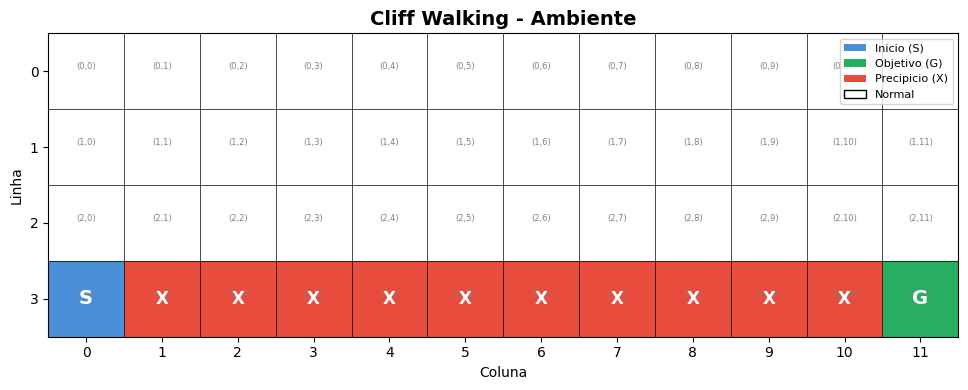

In [ ]:
# 1(c) - Visualizacao do gridworld
# essa funcao mostra o grid com cores pra cada tipo de celula
# e tambem consegue plotar a politica aprendida (setas)


def visualizar_gridworld(env, policy=None, title="Cliff Walking - Gridworld", trajectory=None):
    fig, ax = plt.subplots(1, 1, figsize=(14, 4))
    
    # monta a matriz de cores do grid
    # 0=normal, 1=inicio, 2=objetivo, 3=precipicio
    grid = np.zeros((env.ROWS, env.COLS))
    
    for (r, c) in env.cliff:
        grid[r][c] = 3  # precipicio
    
    grid[env.start[0]][env.start[1]] = 1  # inicio
    grid[env.goal[0]][env.goal[1]] = 2    # objetivo
    
    # cores: branco=normal, azul=inicio, verde=objetivo, vermelho=precipicio
    cmap = ListedColormap(['#FFFFFF', '#4A90D9', '#27AE60', '#E74C3C'])
    ax.imshow(grid, cmap=cmap, aspect='equal')
    
    # grade e rotulos
    for r in range(env.ROWS):
        for c in range(env.COLS):
            ax.text(c, r, f'({r},{c})', ha='center', va='bottom', fontsize=6, color='gray')
            
            # coloca texto nas celulas especiais
            if (r, c) == env.start:
                ax.text(c, r, 'S', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
            elif (r, c) == env.goal:
                ax.text(c, r, 'G', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
            elif (r, c) in env.cliff:
                ax.text(c, r, 'X', ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    
    # se tem politica, desenha as setas
    if policy is not None:
        # setas para cada acao
        arrow_map = {0: (0, -0.3), 1: (0.3, 0), 2: (0, 0.3), 3: (-0.3, 0)}
        for r in range(env.ROWS):
            for c in range(env.COLS):
                if (r, c) in env.cliff or (r, c) == env.goal:
                    continue
                action = policy.get((r, c), None)
                if action is not None:
                    dx, dy = arrow_map[action]
                    ax.annotate('', xy=(c + dx, r + dy), xytext=(c, r),
                               arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    
    # se tem trajetoria, desenha o caminho
    if trajectory is not None:
        rows_t = [s[0] for s in trajectory]
        cols_t = [s[1] for s in trajectory]
        ax.plot(cols_t, rows_t, 'o-', color='#F39C12', markersize=6, linewidth=2, alpha=0.8)
    
    # linhas do grid
    for r in range(env.ROWS + 1):
        ax.axhline(r - 0.5, color='black', linewidth=0.5)
    for c in range(env.COLS + 1):
        ax.axvline(c - 0.5, color='black', linewidth=0.5)
    
    # legenda
    legend_elements = [
        mpatches.Patch(facecolor='#4A90D9', label='Inicio (S)'),
        mpatches.Patch(facecolor='#27AE60', label='Objetivo (G)'),
        mpatches.Patch(facecolor='#E74C3C', label='Precipicio (X)'),
        mpatches.Patch(facecolor='#FFFFFF', edgecolor='black', label='Normal')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(range(env.COLS))
    ax.set_yticks(range(env.ROWS))
    ax.set_xticklabels(range(env.COLS))
    ax.set_yticklabels(range(env.ROWS))
    ax.set_xlabel('Coluna')
    ax.set_ylabel('Linha')
    plt.tight_layout()
    plt.show()

# mostra o gridworld vazio pra verificar que ta tudo certo
env = CliffWalkingEnv()
visualizar_gridworld(env, title="Cliff Walking - Ambiente")

In [4]:
# verificacao extra da logica do precipicio
# vou testar varios cenarios pra garantir que tudo ta correto

env = CliffWalkingEnv()

print("=== Verificacao da logica do precipicio ===")
print()

# teste 1: andar pelo precipicio
env.reset()
state, reward, done = env.step(env.RIGHT)  # (3,0) -> precipicio
assert reward == -100 and state == env.start and not done
print("Teste 1 - Cair no precipicio: PASSOU")
print(f"  Recompensa={reward}, Voltou pro inicio={state}, Done={done}")

# teste 2: chegar no objetivo pela rota segura
env.reset()
env.state = (3, 11)  # coloco direto perto do objetivo pra testar
# na verdade (3,11) ja eh o objetivo, entao vou testar de (2,11)
env.state = (2, 11)
state, reward, done = env.step(env.DOWN)  # (2,11) -> (3,11) = objetivo
assert reward == -1 and state == env.goal and done
print("Teste 2 - Chegar no objetivo: PASSOU")
print(f"  Recompensa={reward}, Estado={state}, Done={done}")

# teste 3: bater na parede (nao sai do grid)
env.reset()
state, reward, done = env.step(env.LEFT)  # (3,0) -> parede, fica em (3,0)
assert state == (3, 0) and reward == -1
print("Teste 3 - Bater na parede esquerda: PASSOU")
print(f"  Estado={state}, Recompensa={reward}")

# teste 4: bater na parede de cima
env.state = (0, 5)
state, reward, done = env.step(env.UP)  # (0,5) -> parede, fica em (0,5)
assert state == (0, 5) and reward == -1
print("Teste 4 - Bater na parede de cima: PASSOU")
print(f"  Estado={state}, Recompensa={reward}")

# teste 5: passo normal no meio do grid
env.state = (1, 5)
state, reward, done = env.step(env.RIGHT)  # (1,5) -> (1,6)
assert state == (1, 6) and reward == -1 and not done
print("Teste 5 - Passo normal: PASSOU")
print(f"  Estado={state}, Recompensa={reward}")

print()
print("Todos os testes passaram! Ambiente funcionando corretamente.")

=== Verificacao da logica do precipicio ===

Teste 1 - Cair no precipicio: PASSOU
  Recompensa=-100, Voltou pro inicio=(3, 0), Done=False
Teste 2 - Chegar no objetivo: PASSOU
  Recompensa=-1, Estado=(3, 11), Done=True
Teste 3 - Bater na parede esquerda: PASSOU
  Estado=(3, 0), Recompensa=-1
Teste 4 - Bater na parede de cima: PASSOU
  Estado=(0, 5), Recompensa=-1
Teste 5 - Passo normal: PASSOU
  Estado=(1, 6), Recompensa=-1

Todos os testes passaram! Ambiente funcionando corretamente.


---
# 2. Agente Tabular Q-Learning
---

In [ ]:
# 2(a) - Tabela Q e loop de atualizacao off-policy
# Q-Learning eh off-policy porque usa max_a Q(s', a) na atualizacao
# independente da acao que realmente foi tomada
# A regra de atualizacao eh:
# Q(s,a) <- Q(s,a) + alpha * [r + gamma * max_a Q(s',a) - Q(s,a)]

class QLearningAgent:
    def __init__(self, env, alpha=0.5, gamma=1.0, epsilon_start=1.0,
                 epsilon_end=0.01, epsilon_decay=0.995):
        self.env = env
        self.alpha = alpha      # taxa de aprendizado
        self.gamma = gamma      # fator de desconto (1.0 pq eh episodico)
        
        # parametros do epsilon-greedy com decaimento
        self.epsilon_start = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.epsilon = epsilon_start
        
        # tabela Q inicializada com zeros
        # uso defaultdict pra nao precisar inicializar todo estado antes
        self.Q = defaultdict(lambda: np.zeros(len(env.ACTIONS)))
    
    # 2(b) - Politica epsilon-greedy com decaimento
    # Com probabilidade epsilon escolhe acao aleatoria
    # Com probabilidade (1-epsilon) escolhe a melhor acao
    # O epsilon vai diminuindo ao longo do treino pra explorar
    # menos e exploitar mais conforme aprende

    def choose_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.choice(self.env.ACTIONS)
        else:
            # escolhe a acao com maior Q, desempatando aleatoriamente
            q_values = self.Q[state]
            max_q = np.max(q_values)
            best_actions = np.where(q_values == max_q)[0]
            return np.random.choice(best_actions)
    
    def decay_epsilon(self):
        # decaimento multiplicativo do epsilon
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
    
    def update(self, state, action, reward, next_state, done):
        # atualizacao Q-Learning (off-policy)
        # usa o maximo Q do proximo estado
        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.Q[next_state])
        
        # erro temporal (TD error)
        td_error = target - self.Q[state][action]
        
        # atualiza Q(s,a)
        self.Q[state][action] += self.alpha * td_error
    
    def get_policy(self):
        # extrai a politica greedy da tabela Q
        policy = {}
        for r in range(self.env.ROWS):
            for c in range(self.env.COLS):
                state = (r, c)
                if state in self.env.cliff or state == self.env.goal:
                    continue
                policy[state] = np.argmax(self.Q[state])
        return policy

print("Classe QLearningAgent definida.")

Classe QLearningAgent definida.


In [ ]:
# 2(c) - Treinamento do Q-Learning com metricas
# Hiperparametros escolhidos:
# - alpha=0.5: valor medio, bom pra ambientes deterministicos
# - gamma=1.0: sem desconto, ja que eh episodico e queremos
#   minimizar a soma total de recompensas
# - epsilon começa em 1.0 (exploracao total) e decai pra 0.01
# - decay=0.995: decaimento suave, chega perto do minimo em ~900 eps
# - 1000 episodios: suficiente pra convergir nesse ambiente

def treinar_qlearning(env, num_episodes=1000, alpha=0.5, gamma=1.0,
                      epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995,
                      max_steps=1000):
    agent = QLearningAgent(env, alpha, gamma, epsilon_start, epsilon_end, epsilon_decay)
    
    # metricas de treinamento
    rewards_per_episode = []
    steps_per_episode = []
    epsilons = []
    
    for ep in range(num_episodes):
        state = env.reset()
        total_reward = 0
        steps = 0
        
        for step in range(max_steps):
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            
            # atualizacao Q-Learning
            agent.update(state, action, reward, next_state, done)
            
            total_reward += reward
            steps += 1
            state = next_state
            
            if done:
                break
        
        rewards_per_episode.append(total_reward)
        steps_per_episode.append(steps)
        epsilons.append(agent.epsilon)
        
        # decai epsilon no final de cada episodio
        agent.decay_epsilon()
    
    return agent, rewards_per_episode, steps_per_episode, epsilons

# treinando o agente
env_tabular = CliffWalkingEnv()
agent_tabular, rewards_tab, steps_tab, epsilons_tab = treinar_qlearning(
    env_tabular, num_episodes=1000
)

print(f"Treinamento Q-Learning concluido!")
print(f"Recompensa media (ultimos 100 eps): {np.mean(rewards_tab[-100:]):.1f}")
print(f"Passos medios (ultimos 100 eps): {np.mean(steps_tab[-100:]):.1f}")
print(f"Epsilon final: {epsilons_tab[-1]:.4f}")

Treinamento Q-Learning concluido!
Recompensa media (ultimos 100 eps): -16.5
Passos medios (ultimos 100 eps): 13.5
Epsilon final: 0.0100


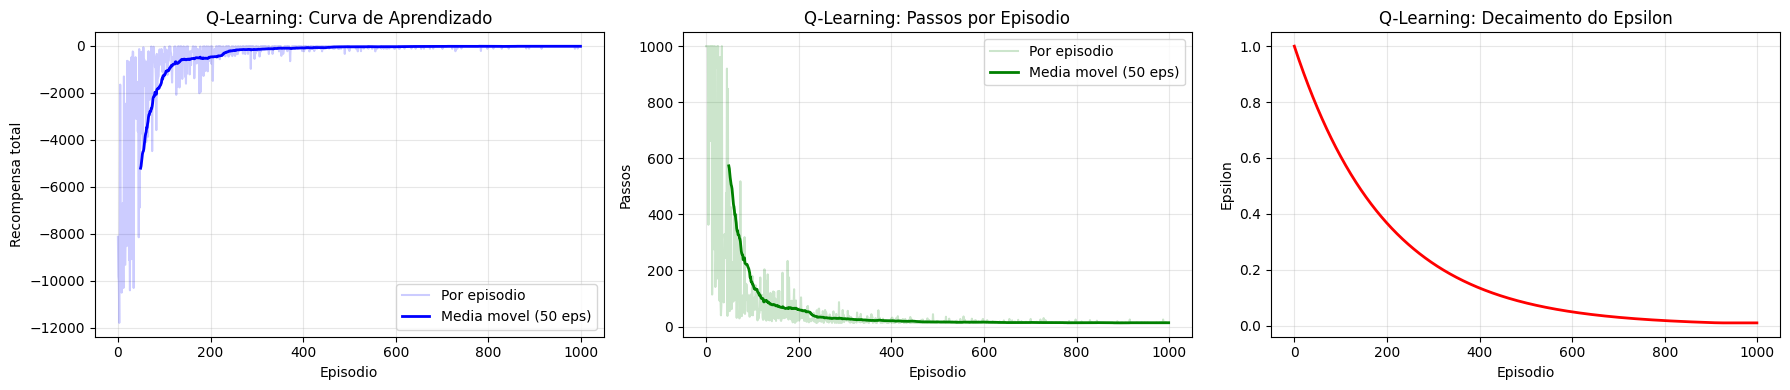

In [7]:
# plotando as metricas de treinamento do Q-Learning

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# curva de aprendizado - recompensa por episodio
window = 50
rewards_smooth = np.convolve(rewards_tab, np.ones(window)/window, mode='valid')
axes[0].plot(rewards_tab, alpha=0.2, color='blue', label='Por episodio')
axes[0].plot(range(window-1, len(rewards_tab)), rewards_smooth, color='blue',
             linewidth=2, label=f'Media movel ({window} eps)')
axes[0].set_xlabel('Episodio')
axes[0].set_ylabel('Recompensa total')
axes[0].set_title('Q-Learning: Curva de Aprendizado')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# passos por episodio
steps_smooth = np.convolve(steps_tab, np.ones(window)/window, mode='valid')
axes[1].plot(steps_tab, alpha=0.2, color='green', label='Por episodio')
axes[1].plot(range(window-1, len(steps_tab)), steps_smooth, color='green',
             linewidth=2, label=f'Media movel ({window} eps)')
axes[1].set_xlabel('Episodio')
axes[1].set_ylabel('Passos')
axes[1].set_title('Q-Learning: Passos por Episodio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# decaimento do epsilon
axes[2].plot(epsilons_tab, color='red', linewidth=2)
axes[2].set_xlabel('Episodio')
axes[2].set_ylabel('Epsilon')
axes[2].set_title('Q-Learning: Decaimento do Epsilon')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

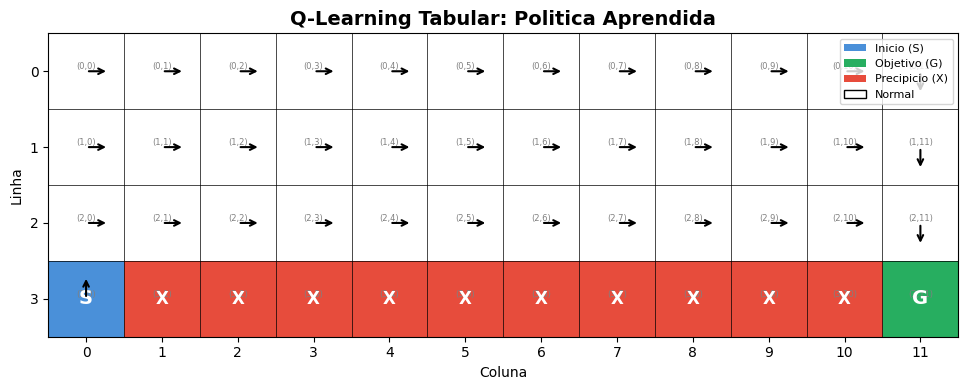

In [8]:
# visualizando a politica aprendida pelo Q-Learning
policy_tab = agent_tabular.get_policy()
visualizar_gridworld(env_tabular, policy=policy_tab,
                     title="Q-Learning Tabular: Politica Aprendida")

# a gente espera que o Q-Learning aprenda o caminho otimo:
# vai pela borda do precipicio (caminho mais curto)
# isso acontece porque Q-Learning eh off-policy e aprende
# a politica greedy diretamente

Trajetoria do Q-Learning (greedy): 13 passos
Recompensa total: -13
Caminho: [(3, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (3, 11)]


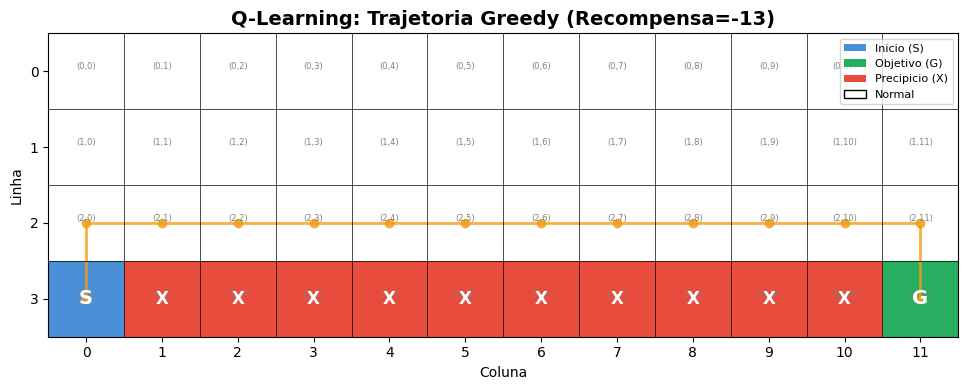

In [9]:
# simulando um episodio com a politica aprendida pra ver o caminho

def simular_episodio(env, agent, greedy=True):
    state = env.reset()
    trajectory = [state]
    total_reward = 0
    
    for _ in range(200):  # limite de seguranca
        if greedy:
            action = np.argmax(agent.Q[state])
        else:
            action = agent.choose_action(state)
        
        next_state, reward, done = env.step(action)
        total_reward += reward
        trajectory.append(next_state)
        state = next_state
        
        if done:
            break
    
    return trajectory, total_reward

trajectory_tab, reward_tab_test = simular_episodio(env_tabular, agent_tabular)
print(f"Trajetoria do Q-Learning (greedy): {len(trajectory_tab)-1} passos")
print(f"Recompensa total: {reward_tab_test}")
print(f"Caminho: {trajectory_tab}")

visualizar_gridworld(env_tabular, trajectory=trajectory_tab,
                     title=f"Q-Learning: Trajetoria Greedy (Recompensa={reward_tab_test})")

---
# 3. Agente com Aproximacao de Funcao e Semi-Gradiente TD
---

In [ ]:
# 3(a) - Definicao e justificativa do vetor de features phi(s,a)
#
# A ideia aqui eh representar Q(s,a) como produto interno entre
# um vetor de pesos w e um vetor de features phi(s,a):
#   Q(s,a,w) = w^T * phi(s,a)
#
# Precisamos definir features que capturem informacao relevante
# sobre o estado e a acao. A gente vai usar:
#
# Features do estado (normalizadas entre 0 e 1):
# 1) linha normalizada: r / (ROWS-1)
# 2) coluna normalizada: c / (COLS-1)
# 3) distancia Manhattan ate o objetivo normalizada
# 4) indicador de proximidade ao precipicio (1 se adjacente)
# 5) indicador de estar na linha do precipicio
#
# Pra cada acao, criamos um vetor separado (one-hot codificado)
# Ou seja, phi(s,a) tem as features do estado concatenadas com
# zeros pra todas as acoes exceto a acao atual
#
# Essa estrutura permite que cada acao tenha seus proprios pesos
# enquanto compartilha a mesma representacao do estado
# O compartilhamento de features entre estados eh justamente
# o que permite a generalizacao - estados parecidos terao
# valores Q parecidos


class FunctionApproxAgent:
    # numero de features por acao
    NUM_STATE_FEATURES = 6  # 5 features + 1 bias
    
    def __init__(self, env, alpha=0.01, gamma=1.0, epsilon_start=1.0,
                 epsilon_end=0.01, epsilon_decay=0.995):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon_start = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.epsilon = epsilon_start
        
        self.n_actions = len(env.ACTIONS)
        # total de features = features_por_acao * n_acoes
        self.n_features = self.NUM_STATE_FEATURES * self.n_actions
        
        # pesos inicializados com valores pequenos aleatorios
        # usar zeros pode causar problema de simetria no inicio
        self.w = np.zeros(self.n_features)
    
    def _state_features(self, state):
        # calcula as features do estado
        r, c = state
        rows = self.env.ROWS
        cols = self.env.COLS
        
        # feature 1: posicao da linha normalizada
        f_row = r / (rows - 1)
        
        # feature 2: posicao da coluna normalizada
        f_col = c / (cols - 1)
        
        # feature 3: distancia Manhattan normalizada ate o objetivo
        goal_r, goal_c = self.env.goal
        max_dist = (rows - 1) + (cols - 1)  # distancia maxima possivel
        dist = abs(r - goal_r) + abs(c - goal_c)
        f_dist = dist / max_dist
        
        # feature 4: proximidade ao precipicio
        # verifica se algum vizinho eh precipicio
        near_cliff = 0.0
        for dr, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
            nr, nc = r + dr, c + dc
            if (nr, nc) in self.env.cliff:
                near_cliff = 1.0
                break
        
        # feature 5: esta na ultima linha (linha do precipicio)
        f_bottom = 1.0 if r == rows - 1 else 0.0
        
        # feature 6: bias (sempre 1)
        f_bias = 1.0
        
        return np.array([f_row, f_col, f_dist, near_cliff, f_bottom, f_bias])
    
    def phi(self, state, action):
        # constroi o vetor phi(s,a) completo
        # eh um vetor grande onde so a parte da acao atual tem valores
        # o resto eh zero (tile coding simplificado por acao)
        features = np.zeros(self.n_features)
        state_feats = self._state_features(state)
        start = action * self.NUM_STATE_FEATURES
        end = start + self.NUM_STATE_FEATURES
        features[start:end] = state_feats
        return features
    
    def Q(self, state, action):
        # Q(s,a,w) = w^T * phi(s,a)
        return np.dot(self.w, self.phi(state, action))
    
    def Q_all_actions(self, state):
        # retorna Q pra todas as acoes num estado
        return np.array([self.Q(state, a) for a in self.env.ACTIONS])
    
    def choose_action(self, state):
        # politica epsilon-greedy (igual ao tabular)
        if np.random.random() < self.epsilon:
            return np.random.choice(self.env.ACTIONS)
        else:
            q_values = self.Q_all_actions(state)
            max_q = np.max(q_values)
            best_actions = np.where(q_values == max_q)[0]
            return np.random.choice(best_actions)
    
    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
    
    # 3(b) - Loop de atualizacao semi-gradiente TD
    # A atualizacao semi-gradiente TD eh:
    # w <- w + alpha * [r + gamma * max_a Q(s',a,w) - Q(s,a,w)] * grad_w Q(s,a,w)
    #
    # Como Q(s,a,w) = w^T * phi(s,a), o gradiente eh simplesmente:
    # grad_w Q(s,a,w) = phi(s,a)
    #
    # Eh "semi-gradiente" porque a gente nao diferencia o target
    # (r + gamma * max Q) em relacao a w, so diferencia Q(s,a,w)
    # Isso eh uma aproximacao, mas funciona bem na pratica
    
    def update(self, state, action, reward, next_state, done):
        # valor atual
        q_current = self.Q(state, action)
        
        # calcula o target
        if done:
            target = reward
        else:
            # max_a Q(s', a, w)
            q_next_max = np.max(self.Q_all_actions(next_state))
            target = reward + self.gamma * q_next_max
        
        # erro TD
        td_error = target - q_current
        
        # gradiente de Q(s,a,w) em relacao a w = phi(s,a)
        gradient = self.phi(state, action)
        
        # atualizacao semi-gradiente
        # w <- w + alpha * td_error * phi(s,a)
        self.w += self.alpha * td_error * gradient
    
    def get_policy(self):
        policy = {}
        for r in range(self.env.ROWS):
            for c in range(self.env.COLS):
                state = (r, c)
                if state in self.env.cliff or state == self.env.goal:
                    continue
                q_values = self.Q_all_actions(state)
                policy[state] = np.argmax(q_values)
        return policy

# verificacao rapida das features
env_test = CliffWalkingEnv()
agent_test = FunctionApproxAgent(env_test)

print("Verificacao do vetor de features:")
print(f"Estado (0,0), features: {agent_test._state_features((0,0))}")
print(f"Estado (3,0), features: {agent_test._state_features((3,0))}")
print(f"Estado (2,5), features: {agent_test._state_features((2,5))}")
print(f"\nDimensao do vetor phi(s,a): {len(agent_test.phi((0,0), 0))}")
print(f"Numero de pesos: {len(agent_test.w)}")

Verificacao do vetor de features:
Estado (0,0), features: [0. 0. 1. 0. 0. 1.]
Estado (3,0), features: [1.         0.         0.78571429 1.         1.         1.        ]
Estado (2,5), features: [0.66666667 0.45454545 0.5        1.         0.         1.        ]

Dimensao do vetor phi(s,a): 24
Numero de pesos: 24


In [ ]:
# 3(c) - Treinamento do agente com aproximacao de funcao
# Hiperparametros:
# - alpha=0.01: taxa menor que no tabular porque com funcao linear
#   uma atualizacao afeta multiplos estados (generalizacao), entao
#   se alpha for muito grande os pesos oscilam e nao convergem
# - gamma=1.0: mesmo motivo do tabular
# - epsilon com mesmo decaimento
# - 1000 episodios pra comparar de forma justa


def treinar_func_approx(env, num_episodes=1000, alpha=0.01, gamma=1.0,
                         epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995,
                         max_steps=1000):
    agent = FunctionApproxAgent(env, alpha, gamma, epsilon_start, epsilon_end, epsilon_decay)
    
    rewards_per_episode = []
    steps_per_episode = []
    epsilons = []
    
    for ep in range(num_episodes):
        state = env.reset()
        total_reward = 0
        steps = 0
        
        for step in range(max_steps):
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            
            # atualizacao semi-gradiente TD
            agent.update(state, action, reward, next_state, done)
            
            total_reward += reward
            steps += 1
            state = next_state
            
            if done:
                break
        
        rewards_per_episode.append(total_reward)
        steps_per_episode.append(steps)
        epsilons.append(agent.epsilon)
        agent.decay_epsilon()
    
    return agent, rewards_per_episode, steps_per_episode, epsilons

# treinando o agente com aproximacao de funcao
env_fa = CliffWalkingEnv()
agent_fa, rewards_fa, steps_fa, epsilons_fa = treinar_func_approx(
    env_fa, num_episodes=1000
)

print(f"Treinamento com Aproximacao de Funcao concluido!")
print(f"Recompensa media (ultimos 100 eps): {np.mean(rewards_fa[-100:]):.1f}")
print(f"Passos medios (ultimos 100 eps): {np.mean(steps_fa[-100:]):.1f}")
print(f"Epsilon final: {epsilons_fa[-1]:.4f}")

Treinamento com Aproximacao de Funcao concluido!
Recompensa media (ultimos 100 eps): -17.4
Passos medios (ultimos 100 eps): 13.5
Epsilon final: 0.0100


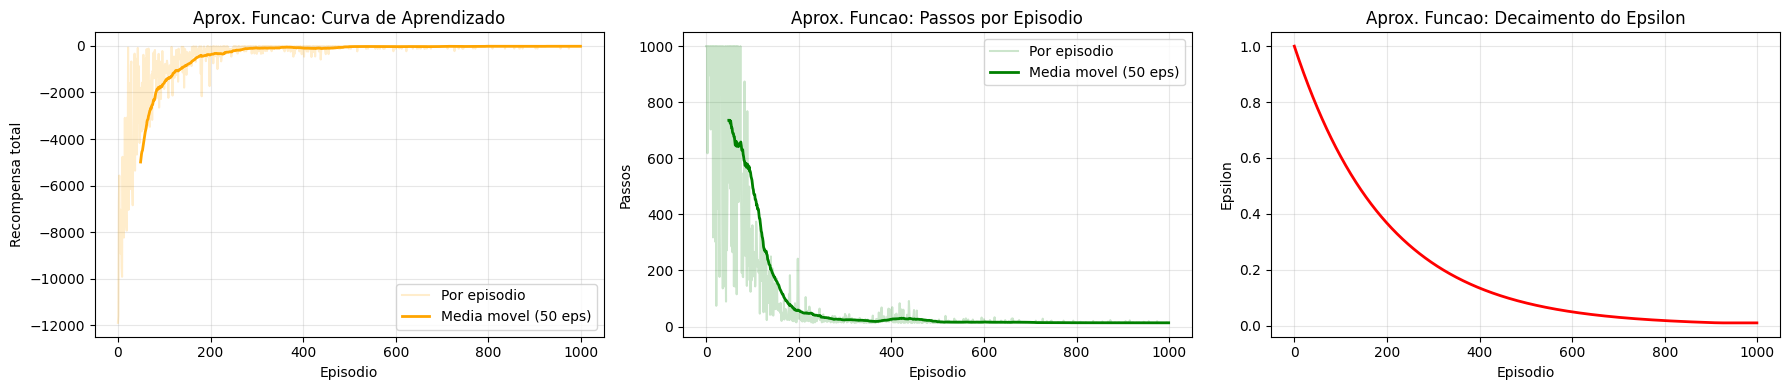

In [12]:
# metricas de treinamento da aproximacao de funcao

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

window = 50
rewards_fa_smooth = np.convolve(rewards_fa, np.ones(window)/window, mode='valid')
axes[0].plot(rewards_fa, alpha=0.2, color='orange', label='Por episodio')
axes[0].plot(range(window-1, len(rewards_fa)), rewards_fa_smooth, color='orange',
             linewidth=2, label=f'Media movel ({window} eps)')
axes[0].set_xlabel('Episodio')
axes[0].set_ylabel('Recompensa total')
axes[0].set_title('Aprox. Funcao: Curva de Aprendizado')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

steps_fa_smooth = np.convolve(steps_fa, np.ones(window)/window, mode='valid')
axes[1].plot(steps_fa, alpha=0.2, color='green', label='Por episodio')
axes[1].plot(range(window-1, len(steps_fa)), steps_fa_smooth, color='green',
             linewidth=2, label=f'Media movel ({window} eps)')
axes[1].set_xlabel('Episodio')
axes[1].set_ylabel('Passos')
axes[1].set_title('Aprox. Funcao: Passos por Episodio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epsilons_fa, color='red', linewidth=2)
axes[2].set_xlabel('Episodio')
axes[2].set_ylabel('Epsilon')
axes[2].set_title('Aprox. Funcao: Decaimento do Epsilon')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

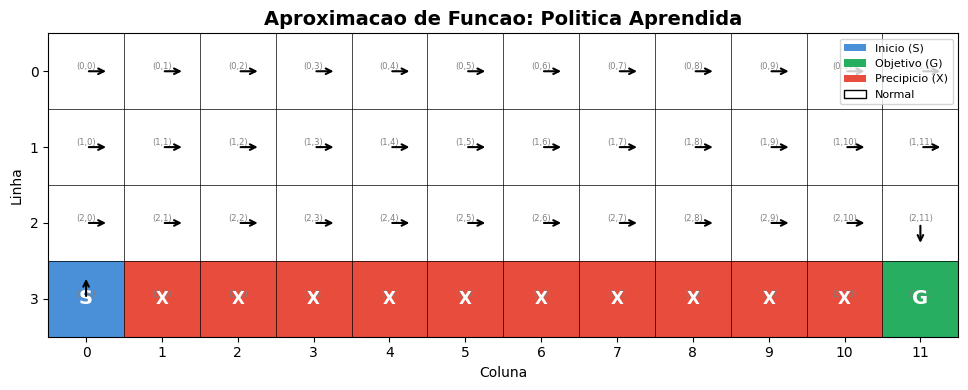

In [13]:
# politica aprendida pelo agente com aproximacao de funcao
policy_fa = agent_fa.get_policy()
visualizar_gridworld(env_fa, policy=policy_fa,
                     title="Aproximacao de Funcao: Politica Aprendida")

Trajetoria da Aprox. Funcao (greedy): 13 passos
Recompensa total: -13
Caminho: [(3, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (3, 11)]


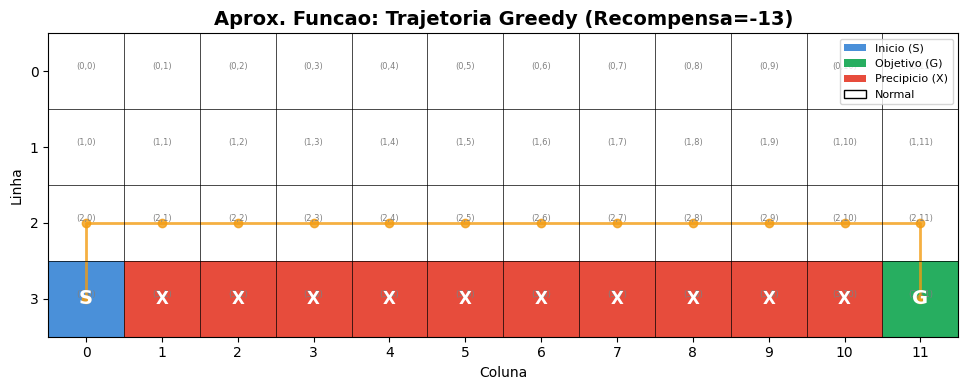

In [14]:
# simulando a trajetoria do agente com aproximacao de funcao

def simular_episodio_fa(env, agent, greedy=True):
    state = env.reset()
    trajectory = [state]
    total_reward = 0
    
    for _ in range(200):
        if greedy:
            q_values = agent.Q_all_actions(state)
            action = np.argmax(q_values)
        else:
            action = agent.choose_action(state)
        
        next_state, reward, done = env.step(action)
        total_reward += reward
        trajectory.append(next_state)
        state = next_state
        
        if done:
            break
    
    return trajectory, total_reward

trajectory_fa, reward_fa_test = simular_episodio_fa(env_fa, agent_fa)
print(f"Trajetoria da Aprox. Funcao (greedy): {len(trajectory_fa)-1} passos")
print(f"Recompensa total: {reward_fa_test}")
print(f"Caminho: {trajectory_fa}")

visualizar_gridworld(env_fa, trajectory=trajectory_fa,
                     title=f"Aprox. Funcao: Trajetoria Greedy (Recompensa={reward_fa_test})")

In [15]:
# vamos olhar os pesos aprendidos pra entender o que o modelo aprendeu
# cada bloco de 6 pesos corresponde a uma acao

feature_names = ['Linha', 'Coluna', 'Dist. Goal', 'Perto Cliff', 'Linha Fundo', 'Bias']
action_names = ['Cima', 'Direita', 'Baixo', 'Esquerda']

print("Pesos aprendidos pelo agente com aproximacao de funcao:")
print("=" * 60)
for a_idx, a_name in enumerate(action_names):
    start = a_idx * FunctionApproxAgent.NUM_STATE_FEATURES
    end = start + FunctionApproxAgent.NUM_STATE_FEATURES
    weights = agent_fa.w[start:end]
    print(f"\nAcao: {a_name}")
    for f_name, w_val in zip(feature_names, weights):
        print(f"  {f_name:15s}: {w_val:+8.3f}")

# interpretacao: pesos negativos grandes pra 'Perto Cliff' e 'Linha Fundo'
# nas acoes Baixo e Direita fazem sentido - o agente aprendeu a evitar
# ir pro precipicio

Pesos aprendidos pelo agente com aproximacao de funcao:

Acao: Cima
  Linha          :   +5.569
  Coluna         :   -0.400
  Dist. Goal     :  -15.799
  Perto Cliff    :   +8.108
  Linha Fundo    :   +0.770
  Bias           :  -14.919

Acao: Direita
  Linha          :  +10.151
  Coluna         :   +1.452
  Dist. Goal     :  -11.819
  Perto Cliff    :   +0.135
  Linha Fundo    : -104.564
  Bias           :   -8.503

Acao: Baixo
  Linha          :  +10.595
  Coluna         :   +3.627
  Dist. Goal     :  -15.589
  Perto Cliff    : -103.834
  Linha Fundo    : +102.893
  Bias           :  -10.469

Acao: Esquerda
  Linha          :   +5.694
  Coluna         :   -0.554
  Dist. Goal     :  -13.225
  Perto Cliff    :   +6.874
  Linha Fundo    :   -3.023
  Bias           :  -12.440


---
# 4. Analise Comparativa
---

In [ ]:
# 4(a) - Comparacao das curvas de aprendizado---
# pra uma comparacao mais justa, vamos rodar multiplas seeds
# e pegar a media e desvio padrao

n_runs = 10
n_episodes = 1000

all_rewards_tab = []
all_rewards_fa = []

for run in range(n_runs):
    np.random.seed(run * 42)
    
    # Q-Learning tabular
    env_t = CliffWalkingEnv()
    _, rewards_t, _, _ = treinar_qlearning(env_t, num_episodes=n_episodes)
    all_rewards_tab.append(rewards_t)
    
    # Aproximacao de funcao
    env_f = CliffWalkingEnv()
    _, rewards_f, _, _ = treinar_func_approx(env_f, num_episodes=n_episodes)
    all_rewards_fa.append(rewards_f)

all_rewards_tab = np.array(all_rewards_tab)
all_rewards_fa = np.array(all_rewards_fa)

print(f"Rodamos {n_runs} execucoes de cada agente com {n_episodes} episodios cada")

Rodamos 10 execucoes de cada agente com 1000 episodios cada


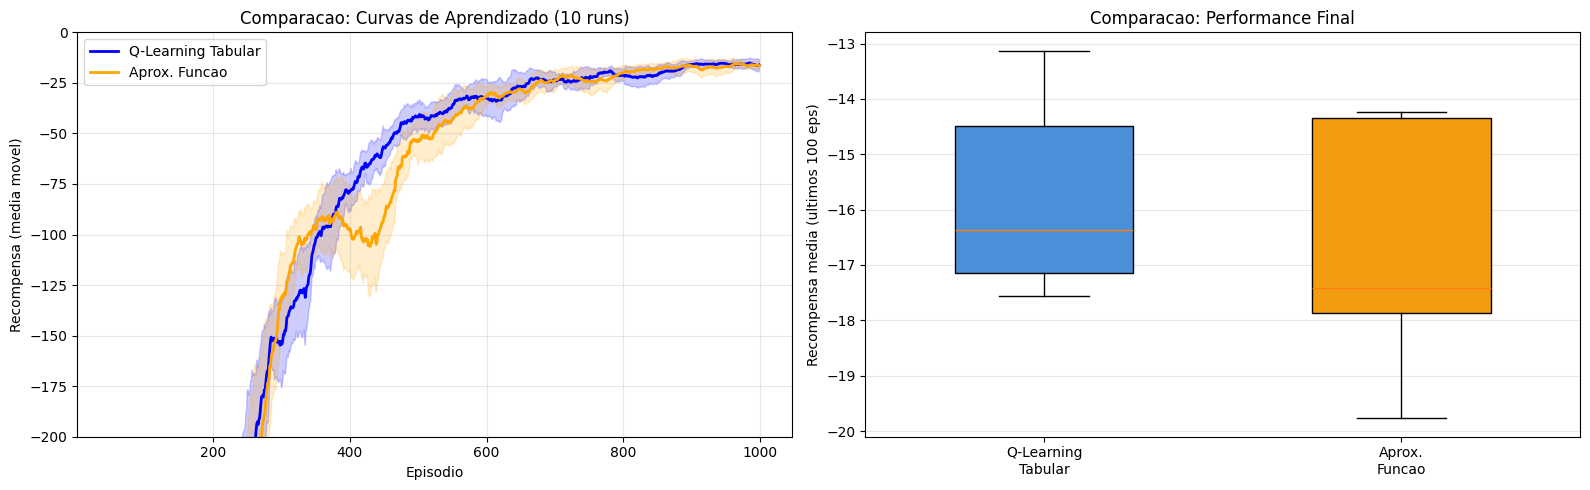


Recompensa media final (ultimos 100 eps):
  Q-Learning Tabular: -15.8 +/- 1.5
  Aprox. Funcao:      -16.6 +/- 2.0


In [17]:
# comparacao das curvas de aprendizado com media e intervalo de confianca

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

window = 50

# suaviza cada run e depois calcula media/std
def smooth_runs(all_rewards, window):
    smoothed = []
    for run_rewards in all_rewards:
        s = np.convolve(run_rewards, np.ones(window)/window, mode='valid')
        smoothed.append(s)
    smoothed = np.array(smoothed)
    return smoothed

smoothed_tab = smooth_runs(all_rewards_tab, window)
smoothed_fa = smooth_runs(all_rewards_fa, window)

mean_tab = np.mean(smoothed_tab, axis=0)
std_tab = np.std(smoothed_tab, axis=0)
mean_fa = np.mean(smoothed_fa, axis=0)
std_fa = np.std(smoothed_fa, axis=0)

x = range(window-1, n_episodes)

# grafico 1: ambos juntos
axes[0].plot(x, mean_tab, color='blue', linewidth=2, label='Q-Learning Tabular')
axes[0].fill_between(x, mean_tab - std_tab, mean_tab + std_tab, alpha=0.2, color='blue')
axes[0].plot(x, mean_fa, color='orange', linewidth=2, label='Aprox. Funcao')
axes[0].fill_between(x, mean_fa - std_fa, mean_fa + std_fa, alpha=0.2, color='orange')
axes[0].set_xlabel('Episodio')
axes[0].set_ylabel('Recompensa (media movel)')
axes[0].set_title(f'Comparacao: Curvas de Aprendizado ({n_runs} runs)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([-200, 0])

# grafico 2: recompensa final (ultimos 100 episodios)
final_tab = [np.mean(run[-100:]) for run in all_rewards_tab]
final_fa = [np.mean(run[-100:]) for run in all_rewards_fa]

positions = [1, 2]
bp = axes[1].boxplot([final_tab, final_fa], positions=positions, widths=0.5,
                      patch_artist=True)
bp['boxes'][0].set_facecolor('#4A90D9')
bp['boxes'][1].set_facecolor('#F39C12')
axes[1].set_xticks(positions)
axes[1].set_xticklabels(['Q-Learning\nTabular', 'Aprox.\nFuncao'])
axes[1].set_ylabel('Recompensa media (ultimos 100 eps)')
axes[1].set_title('Comparacao: Performance Final')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nRecompensa media final (ultimos 100 eps):")
print(f"  Q-Learning Tabular: {np.mean(final_tab):.1f} +/- {np.std(final_tab):.1f}")
print(f"  Aprox. Funcao:      {np.mean(final_fa):.1f} +/- {np.std(final_fa):.1f}")

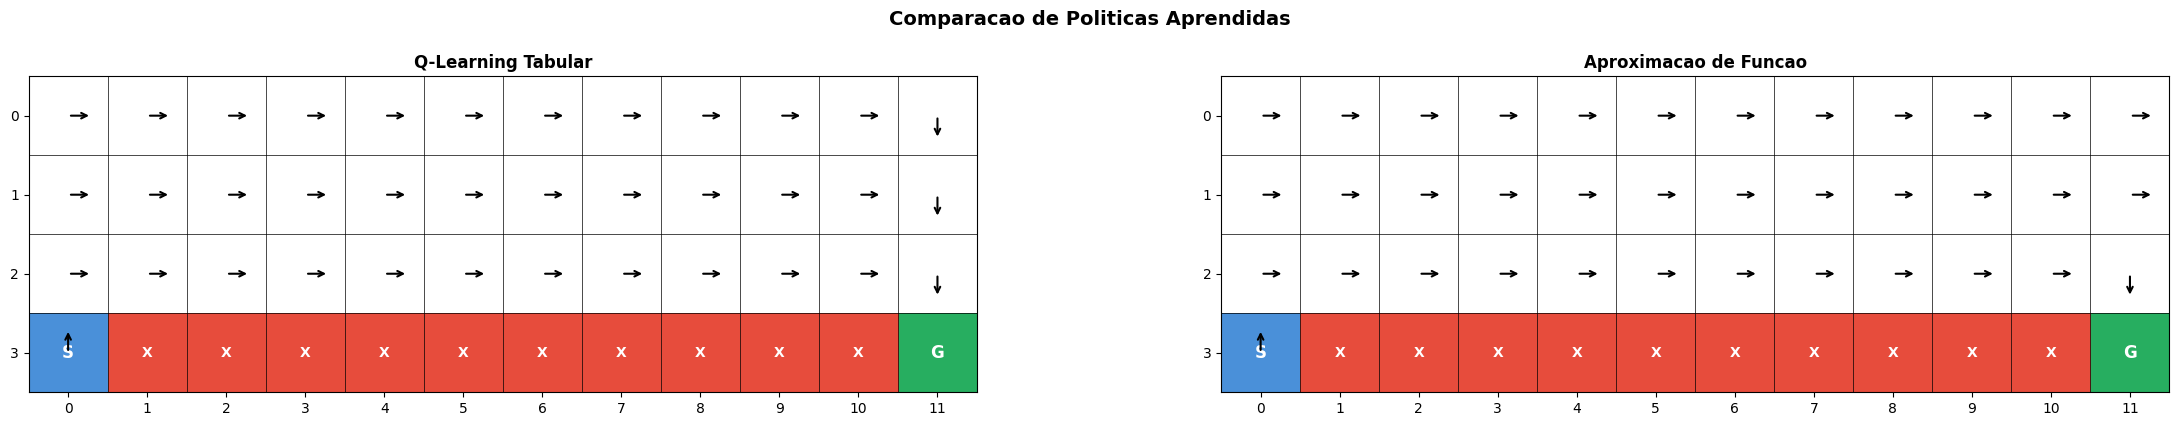


Diferencas entre as politicas: 2/37 estados (5.4%)


In [18]:
# comparacao das politicas aprendidas lado a lado

fig, axes = plt.subplots(1, 2, figsize=(24, 4))

# usa os agentes do treinamento principal (nao das multiplas runs)
# pra ter uma visualizacao representativa
np.random.seed(42)
env_tab_final = CliffWalkingEnv()
agent_tab_final, _, _, _ = treinar_qlearning(env_tab_final, num_episodes=1000)

env_fa_final = CliffWalkingEnv()
agent_fa_final, _, _, _ = treinar_func_approx(env_fa_final, num_episodes=1000)

# funcao auxiliar pra plotar politica num eixo especifico
def plot_policy_on_ax(ax, env, policy, title):
    grid = np.zeros((env.ROWS, env.COLS))
    for (r, c) in env.cliff:
        grid[r][c] = 3
    grid[env.start[0]][env.start[1]] = 1
    grid[env.goal[0]][env.goal[1]] = 2
    
    cmap = ListedColormap(['#FFFFFF', '#4A90D9', '#27AE60', '#E74C3C'])
    ax.imshow(grid, cmap=cmap, aspect='equal')
    
    arrow_map = {0: (0, -0.3), 1: (0.3, 0), 2: (0, 0.3), 3: (-0.3, 0)}
    for r in range(env.ROWS):
        for c in range(env.COLS):
            if (r, c) in env.cliff:
                ax.text(c, r, 'X', ha='center', va='center', fontsize=10, color='white', fontweight='bold')
                continue
            if (r, c) == env.goal:
                ax.text(c, r, 'G', ha='center', va='center', fontsize=12, color='white', fontweight='bold')
                continue
            if (r, c) == env.start:
                ax.text(c, r, 'S', ha='center', va='center', fontsize=12, color='white', fontweight='bold')
            
            action = policy.get((r, c), None)
            if action is not None:
                dx, dy = arrow_map[action]
                ax.annotate('', xy=(c + dx, r + dy), xytext=(c, r),
                           arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    
    for r in range(env.ROWS + 1):
        ax.axhline(r - 0.5, color='black', linewidth=0.5)
    for c in range(env.COLS + 1):
        ax.axvline(c - 0.5, color='black', linewidth=0.5)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(range(env.COLS))
    ax.set_yticks(range(env.ROWS))

policy_tab_final = agent_tab_final.get_policy()
policy_fa_final = agent_fa_final.get_policy()

plot_policy_on_ax(axes[0], env_tab_final, policy_tab_final, 'Q-Learning Tabular')
plot_policy_on_ax(axes[1], env_fa_final, policy_fa_final, 'Aproximacao de Funcao')

plt.suptitle('Comparacao de Politicas Aprendidas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# contando diferencas entre as politicas
diferencas = 0
total = 0
for r in range(4):
    for c in range(12):
        s = (r, c)
        if s in env_tab_final.cliff or s == env_tab_final.goal:
            continue
        total += 1
        a_tab = policy_tab_final.get(s)
        a_fa = policy_fa_final.get(s)
        if a_tab != a_fa:
            diferencas += 1

print(f"\nDiferencas entre as politicas: {diferencas}/{total} estados ({100*diferencas/total:.1f}%)")

In [ ]:
# 4(b) - Discussao conceitual
# Aqui vamos analisar o que muda ao trocar a tabela Q por uma
# funcao parametrizada, em tres aspectos:
# generalizacao, estabilidade e limitacoes


print("=" * 70)
print("DISCUSSAO: TABELA Q vs APROXIMACAO DE FUNCAO")
print("=" * 70)

print("""
GENERALIZACAO:
- Na tabela Q, cada par (estado, acao) tem um valor independente.
  Isso significa que o agente precisa visitar CADA estado varias
  vezes pra aprender. Se o grid fosse maior (ex: 100x100), seriam
  40.000 estados x 4 acoes = 160.000 entradas na tabela.
  
- Com aproximacao de funcao, temos apenas 24 pesos (6 features x 4 acoes).
  Quando o agente aprende que "estar perto do precipicio + ir pra baixo
  eh ruim", isso se generaliza pra TODOS os estados proximos ao precipicio,
  mesmo os que nunca foram visitados.
  
- Essa generalizacao eh especialmente util em ambientes grandes ou
  continuos, onde eh impossivel visitar todos os estados.

ESTABILIDADE:
- O Q-Learning tabular com atualizacao off-policy converge garantidamente
  para Q* (sob condicoes de Robbins-Monro pra alpha).
  
- Com aproximacao de funcao, a convergencia NAO eh garantida!
  O chamado "deadly triad" (bootstrapping + funcao de aproximacao +
  treinamento off-policy) pode causar divergencia.
  
- Na pratica, a funcao linear eh mais estavel que redes neurais,
  mas ainda pode oscilar. Por isso usamos alpha menor (0.01 vs 0.5).

LIMITACOES:
- Uma funcao linear so consegue representar relacoes lineares entre
  features e valores Q. Se a estrutura do problema for nao-linear,
  a aproximacao sera pobre.
  
- A qualidade depende muito da escolha das features. Features ruins
  = aproximacao ruim, nao importa quanto treine.
  
- No Cliff Walking, o ambiente eh pequeno o suficiente pra tabela Q
  funcionar perfeitamente. A aproximacao de funcao brilha mais em
  ambientes grandes onde a tabela seria impraticavel.
""")

DISCUSSAO: TABELA Q vs APROXIMACAO DE FUNCAO

GENERALIZACAO:
- Na tabela Q, cada par (estado, acao) tem um valor independente.
  Isso significa que o agente precisa visitar CADA estado varias
  vezes pra aprender. Se o grid fosse maior (ex: 100x100), seriam
  40.000 estados x 4 acoes = 160.000 entradas na tabela.

- Com aproximacao de funcao, temos apenas 24 pesos (6 features x 4 acoes).
  Quando o agente aprende que "estar perto do precipicio + ir pra baixo
  eh ruim", isso se generaliza pra TODOS os estados proximos ao precipicio,
  mesmo os que nunca foram visitados.

- Essa generalizacao eh especialmente util em ambientes grandes ou
  continuos, onde eh impossivel visitar todos os estados.

ESTABILIDADE:
- O Q-Learning tabular com atualizacao off-policy converge garantidamente
  para Q* (sob condicoes de Robbins-Monro pra alpha).

- Com aproximacao de funcao, a convergencia NAO eh garantida!
  O chamado "deadly triad" (bootstrapping + funcao de aproximacao +
  treinamento off-polic

In [ ]:
# 4(c) - Caso onde a generalizacao eh prejudicial
# A generalizacao da aproximacao de funcao pode ser prejudicial
# quando estados que parecem similares nas features exigem
# comportamentos diferentes.
#
# No Cliff Walking, o exemplo classico eh nos cantos:
# O estado (3,0) (inicio) e os estados (3,1)...(3,10) (precipicio)
# tem features muito parecidas (mesma linha, proximos um do outro)
# mas exigem comportamentos COMPLETAMENTE diferentes.
#
# Quando o agente aprende que "na linha 3, ir pra direita eh bom"
# (porque precisa ir pra direita pra chegar no objetivo), essa
# generalizacao eh PERIGOSA pro estado (3,0) porque ir pra direita
# de la cai no precipicio.
#
# Vamos visualizar esse problema analisando os valores Q

print("=" * 70)
print("CASO PREJUDICIAL DA GENERALIZACAO")
print("=" * 70)

# vamos comparar os valores Q dos dois agentes pra estados criticos
print("\nValores Q no estado CRITICO (3,0) - Inicio:")
print("-" * 50)

print("\nQ-Learning Tabular:")
for a in range(4):
    q_val = agent_tab_final.Q[(3,0)][a]
    print(f"  {CliffWalkingEnv.ACTION_NAMES[a]:10s}: {q_val:+8.2f}")

print("\nAprox. Funcao:")
for a in range(4):
    q_val = agent_fa_final.Q((3,0), a)
    print(f"  {CliffWalkingEnv.ACTION_NAMES[a]:10s}: {q_val:+8.2f}")

# comparacao em estados adjacentes
print("\n" + "=" * 50)
print("Valores Q pro estado (2,1) - Logo acima do precipicio:")
print("-" * 50)

print("\nQ-Learning Tabular:")
for a in range(4):
    q_val = agent_tab_final.Q[(2,1)][a]
    print(f"  {CliffWalkingEnv.ACTION_NAMES[a]:10s}: {q_val:+8.2f}")

print("\nAprox. Funcao:")
for a in range(4):
    q_val = agent_fa_final.Q((2,1), a)
    print(f"  {CliffWalkingEnv.ACTION_NAMES[a]:10s}: {q_val:+8.2f}")

CASO PREJUDICIAL DA GENERALIZACAO

Valores Q no estado CRITICO (3,0) - Inicio:
--------------------------------------------------

Q-Learning Tabular:
  Cima      :   -13.00
  Direita   :  -113.00
  Baixo     :   -14.00
  Esquerda  :   -14.00

Aprox. Funcao:
  Cima      :   -12.89
  Direita   :  -112.07
  Baixo     :   -13.06
  Esquerda  :   -13.29

Valores Q pro estado (2,1) - Logo acima do precipicio:
--------------------------------------------------

Q-Learning Tabular:
  Cima      :   -13.00
  Direita   :   -11.00
  Baixo     :  -113.00
  Esquerda  :   -13.00

Aprox. Funcao:
  Cima      :   -15.55
  Direita   :   -10.76
  Baixo     :  -119.16
  Esquerda  :   -12.21


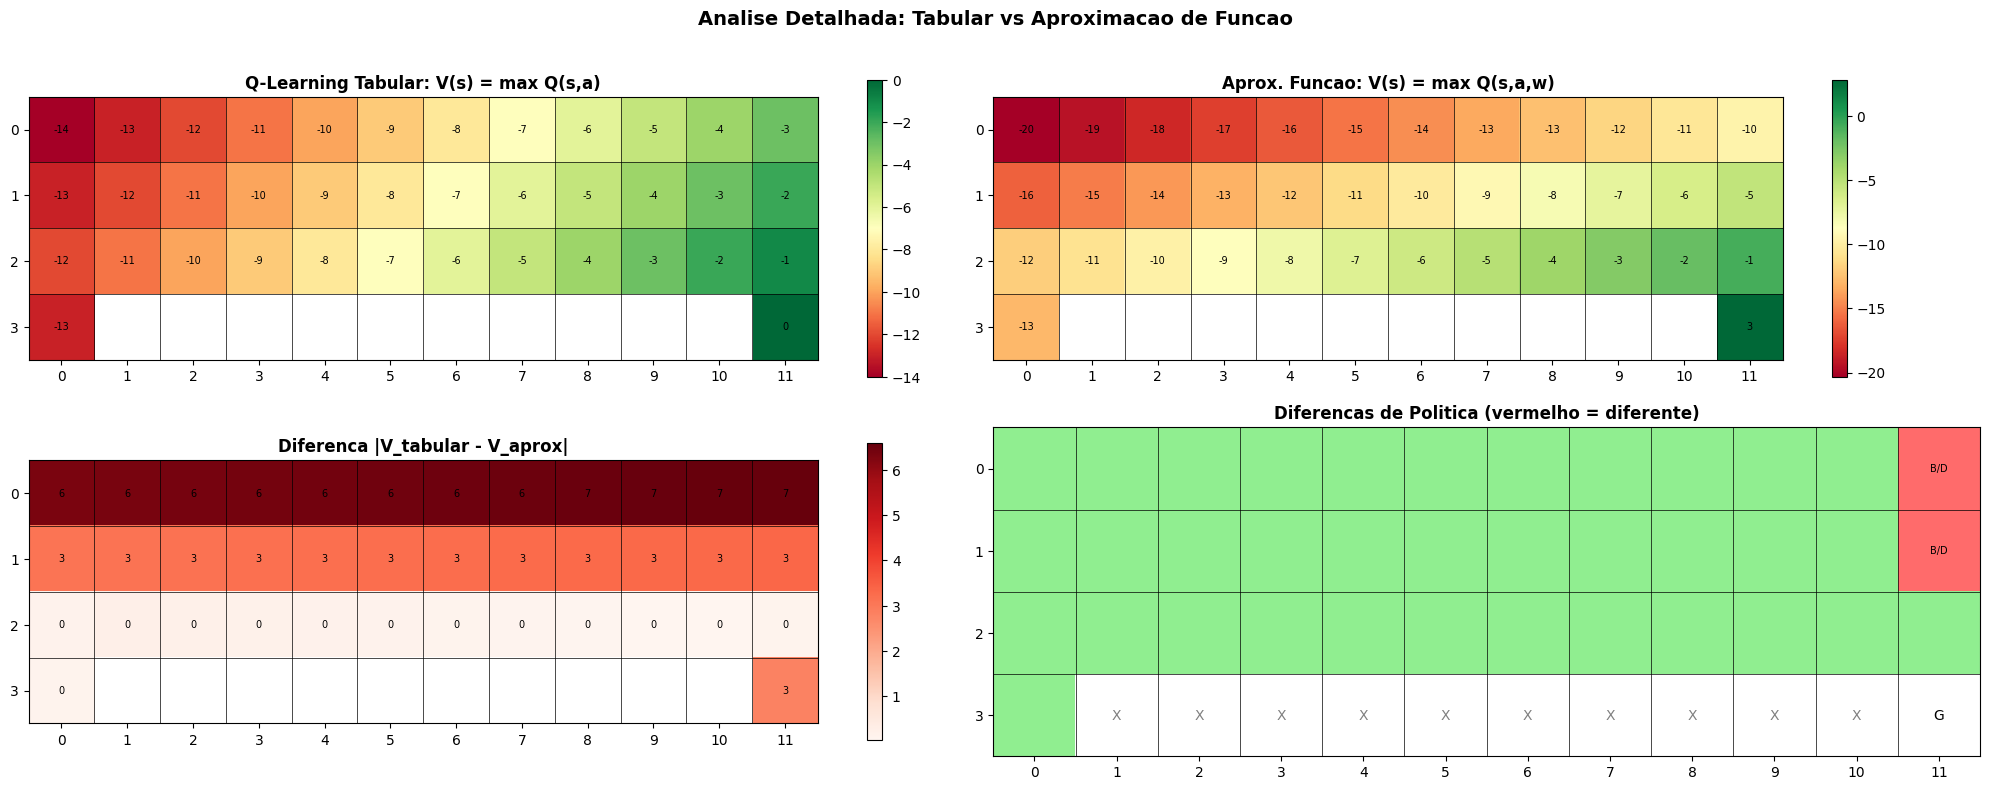

In [21]:
# vamos criar um mapa de calor dos valores Q pra visualizar
# onde a aproximacao de funcao erra mais

fig, axes = plt.subplots(2, 2, figsize=(20, 8))

# calcula V(s) = max_a Q(s,a) pra cada agente
V_tab = np.full((4, 12), np.nan)
V_fa = np.full((4, 12), np.nan)

for r in range(4):
    for c in range(12):
        s = (r, c)
        if s not in env_tab_final.cliff:
            V_tab[r][c] = np.max(agent_tab_final.Q[s])
            V_fa[r][c] = np.max(agent_fa_final.Q_all_actions(s))

# valor do estado (tabular)
im1 = axes[0][0].imshow(V_tab, cmap='RdYlGn', aspect='equal')
axes[0][0].set_title('Q-Learning Tabular: V(s) = max Q(s,a)', fontweight='bold')
plt.colorbar(im1, ax=axes[0][0], shrink=0.8)
for r in range(4):
    for c in range(12):
        if not np.isnan(V_tab[r][c]):
            axes[0][0].text(c, r, f'{V_tab[r][c]:.0f}', ha='center', va='center', fontsize=7)
        else:
            axes[0][0].text(c, r, 'X', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

# valor do estado (aprox funcao)
im2 = axes[0][1].imshow(V_fa, cmap='RdYlGn', aspect='equal')
axes[0][1].set_title('Aprox. Funcao: V(s) = max Q(s,a,w)', fontweight='bold')
plt.colorbar(im2, ax=axes[0][1], shrink=0.8)
for r in range(4):
    for c in range(12):
        if not np.isnan(V_fa[r][c]):
            axes[0][1].text(c, r, f'{V_fa[r][c]:.0f}', ha='center', va='center', fontsize=7)
        else:
            axes[0][1].text(c, r, 'X', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

# diferenca entre os dois (onde a aprox erra mais)
V_diff = np.full((4, 12), np.nan)
for r in range(4):
    for c in range(12):
        if not np.isnan(V_tab[r][c]) and not np.isnan(V_fa[r][c]):
            V_diff[r][c] = abs(V_tab[r][c] - V_fa[r][c])

im3 = axes[1][0].imshow(V_diff, cmap='Reds', aspect='equal')
axes[1][0].set_title('Diferenca |V_tabular - V_aprox|', fontweight='bold')
plt.colorbar(im3, ax=axes[1][0], shrink=0.8)
for r in range(4):
    for c in range(12):
        if not np.isnan(V_diff[r][c]):
            axes[1][0].text(c, r, f'{V_diff[r][c]:.0f}', ha='center', va='center', fontsize=7)
        else:
            axes[1][0].text(c, r, 'X', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

# diferenca de politica
policy_diff = np.zeros((4, 12))
for r in range(4):
    for c in range(12):
        s = (r, c)
        if s in env_tab_final.cliff or s == env_tab_final.goal:
            policy_diff[r][c] = np.nan
            continue
        a_tab = policy_tab_final.get(s)
        a_fa = policy_fa_final.get(s)
        if a_tab != a_fa:
            policy_diff[r][c] = 1

cmap_diff = ListedColormap(['#90EE90', '#FF6B6B'])
im4 = axes[1][1].imshow(policy_diff, cmap=cmap_diff, aspect='equal', vmin=0, vmax=1)
axes[1][1].set_title('Diferencas de Politica (vermelho = diferente)', fontweight='bold')
for r in range(4):
    for c in range(12):
        s = (r, c)
        if s in env_tab_final.cliff:
            axes[1][1].text(c, r, 'X', ha='center', va='center', fontsize=10, color='gray')
        elif s == env_tab_final.goal:
            axes[1][1].text(c, r, 'G', ha='center', va='center', fontsize=10)
        elif policy_diff[r][c] == 1:
            a_t = CliffWalkingEnv.ACTION_NAMES[policy_tab_final[s]][0]
            a_f = CliffWalkingEnv.ACTION_NAMES[policy_fa_final[s]][0]
            axes[1][1].text(c, r, f'{a_t}/{a_f}', ha='center', va='center', fontsize=7)

for ax in axes.flat:
    ax.set_xticks(range(12))
    ax.set_yticks(range(4))
    for rr in range(5):
        ax.axhline(rr - 0.5, color='black', linewidth=0.5)
    for cc in range(13):
        ax.axvline(cc - 0.5, color='black', linewidth=0.5)

plt.suptitle('Analise Detalhada: Tabular vs Aproximacao de Funcao', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# demonstracao explicita de quando a generalizacao atrapalha
# o problema eh que a funcao linear nao consegue representar
# descontinuidades. No Cliff Walking, existe uma descontinuidade
# abrupta entre os estados normais e o precipicio.
#
# por exemplo: (2,5) e (3,5) sao vizinhos, tem features parecidas
# (mesma coluna, linhas adjacentes), mas um eh seguro e outro eh
# precipicio. A funcao linear tenta interpolar entre eles e acaba
# com valores imprecisos pra ambos.
#
# outro caso: estados (2,0) e (2,1) sao vizinhos, mas (2,0) pode
# ir pra baixo com seguranca (volta pro inicio) enquanto (2,1) nao
# pode (cairia no precipicio). A generalizacao faz o agente tratar
# esses estados de forma mais similar do que deveriam ser.


print("=" * 70)
print("DEMONSTRACAO: GENERALIZACAO PREJUDICIAL")
print("=" * 70)

# mostra que as features sao similares para estados que deveriam
# ter comportamentos diferentes
print("\nFeatures de estados que exigem comportamentos DIFERENTES:")
print("-" * 50)

estados_criticos = [(2, 0), (2, 1), (2, 5), (2, 10), (3, 0)]
for s in estados_criticos:
    feats = agent_fa_final._state_features(s)
    acao_tab = CliffWalkingEnv.ACTION_NAMES[policy_tab_final[s]]
    acao_fa = CliffWalkingEnv.ACTION_NAMES[policy_fa_final[s]]
    print(f"  Estado {s}: features={np.round(feats, 2)}")
    print(f"    Acao tabular={acao_tab}, Acao aprox={acao_fa}")
    if acao_tab != acao_fa:
        print(f"    >>> DIFERENTE! A generalizacao causou uma acao errada aqui")
    print()

# nota que (2,1) tem perto_cliff=1 e (2,0) tambem (porque (3,1) eh cliff)
# mas (2,0) pode ir pra baixo com seguranca (vai pro (3,0) = inicio)
# a funcao linear nao consegue fazer essa distincao fina

print("\nPor que isso acontece?")
print("-" * 50)
print("A funcao linear compartilha pesos entre TODOS os estados.")
print("Quando atualiza w por causa de uma experiencia em (2,5),")
print("os valores Q de (2,0), (2,1), etc. tambem mudam, porque")
print("as features sao parecidas.")
print("")
print("No tabular, Q(2,5) e Q(2,0) sao completamente independentes.")
print("Cada estado aprende seu proprio valor sem interferencia.")
print("")
print("Conclusao: em ambientes pequenos com descontinuidades")
print("(como o precipicio), a generalizacao mais atrapalha")
print("do que ajuda. A tabela Q resolve perfeitamente porque")
print("o espaco de estados eh pequeno o suficiente.")

DEMONSTRACAO: GENERALIZACAO PREJUDICIAL

Features de estados que exigem comportamentos DIFERENTES:
--------------------------------------------------
  Estado (2, 0): features=[0.67 0.   0.86 0.   0.   1.  ]
    Acao tabular=Direita, Acao aprox=Direita

  Estado (2, 1): features=[0.67 0.09 0.79 1.   0.   1.  ]
    Acao tabular=Direita, Acao aprox=Direita

  Estado (2, 5): features=[0.67 0.45 0.5  1.   0.   1.  ]
    Acao tabular=Direita, Acao aprox=Direita

  Estado (2, 10): features=[0.67 0.91 0.14 1.   0.   1.  ]
    Acao tabular=Direita, Acao aprox=Direita

  Estado (3, 0): features=[1.   0.   0.79 1.   1.   1.  ]
    Acao tabular=Cima, Acao aprox=Cima


Por que isso acontece?
--------------------------------------------------
A funcao linear compartilha pesos entre TODOS os estados.
Quando atualiza w por causa de uma experiencia em (2,5),
os valores Q de (2,0), (2,1), etc. tambem mudam, porque
as features sao parecidas.

No tabular, Q(2,5) e Q(2,0) sao completamente independentes.


In [ ]:
# velocidade de convergencia
# vamos ver quantos episodios cada agente precisa pra atingir
# um nivel de performance "aceitavel" (recompensa > -20)


threshold = -20  # recompensa considerada "boa" (caminho otimo eh -13)
window_conv = 50

def episodio_convergencia(all_rewards, threshold, window):
    convergencias = []
    for run_rewards in all_rewards:
        smoothed = np.convolve(run_rewards, np.ones(window)/window, mode='valid')
        convergiu = np.where(smoothed >= threshold)[0]
        if len(convergiu) > 0:
            convergencias.append(convergiu[0] + window)
        else:
            convergencias.append(None)
    return convergencias

conv_tab = episodio_convergencia(all_rewards_tab, threshold, window_conv)
conv_fa = episodio_convergencia(all_rewards_fa, threshold, window_conv)

print(f"Episodio de convergencia (media movel > {threshold}):")
print(f"\nQ-Learning Tabular:")
for i, c in enumerate(conv_tab):
    status = f"ep {c}" if c is not None else "nao convergiu"
    print(f"  Run {i+1}: {status}")

print(f"\nAprox. Funcao:")
for i, c in enumerate(conv_fa):
    status = f"ep {c}" if c is not None else "nao convergiu"
    print(f"  Run {i+1}: {status}")

# media
conv_tab_valid = [c for c in conv_tab if c is not None]
conv_fa_valid = [c for c in conv_fa if c is not None]

print(f"\nMedia de convergencia:")
if conv_tab_valid:
    print(f"  Tabular: {np.mean(conv_tab_valid):.0f} episodios ({len(conv_tab_valid)}/{n_runs} convergiram)")
if conv_fa_valid:
    print(f"  Aprox.:  {np.mean(conv_fa_valid):.0f} episodios ({len(conv_fa_valid)}/{n_runs} convergiram)")

Episodio de convergencia (media movel > -20):

Q-Learning Tabular:
  Run 1: ep 557
  Run 2: ep 780
  Run 3: ep 664
  Run 4: ep 680
  Run 5: ep 688
  Run 6: ep 632
  Run 7: ep 728
  Run 8: ep 664
  Run 9: ep 660
  Run 10: ep 638

Aprox. Funcao:
  Run 1: ep 733
  Run 2: ep 714
  Run 3: ep 671
  Run 4: ep 701
  Run 5: ep 645
  Run 6: ep 708
  Run 7: ep 667
  Run 8: ep 680
  Run 9: ep 586
  Run 10: ep 732

Media de convergencia:
  Tabular: 669 episodios (10/10 convergiram)
  Aprox.:  684 episodios (10/10 convergiram)


In [ ]:

print("=" * 70)
print("RESUMO COMPARATIVO")
print("=" * 70)
print(f"{'Metrica':<35s} {'Q-Learning':>15s} {'Aprox. Funcao':>15s}")
print("-" * 70)
print(f"{'Numero de parametros':<35s} {'48 x 4 = 192':>15s} {'6 x 4 = 24':>15s}")
print(f"{'Alpha (taxa aprendizado)':<35s} {'0.5':>15s} {'0.01':>15s}")
print(f"{'Gamma':<35s} {'1.0':>15s} {'1.0':>15s}")
print(f"{'Epsilon final':<35s} {'0.01':>15s} {'0.01':>15s}")

r_tab_mean = np.mean(final_tab)
r_fa_mean = np.mean(final_fa)
print(f"{'Recomp. media final (100 eps)':<35s} {r_tab_mean:>15.1f} {r_fa_mean:>15.1f}")

# caminho otimo eh 13 passos (sobe 1, anda 11 pra direita, desce 1)
print(f"{'Caminho otimo (13 passos = -13)':<35s} {'Sim':>15s} {'Pode variar':>15s}")
print(f"{'Convergencia garantida':<35s} {'Sim':>15s} {'Nao':>15s}")
print(f"{'Generalizacao':<35s} {'Nenhuma':>15s} {'Sim (linear)':>15s}")
print(f"{'Escalabilidade':<35s} {'Limitada':>15s} {'Boa':>15s}")

print("\n" + "=" * 70)
print("CONCLUSAO")
print("=" * 70)
print("""
O Q-Learning tabular converge mais rapido e atinge performance melhor
neste ambiente especifico (4x12 = 48 estados). Isso eh esperado porque:

1) O espaco de estados eh pequeno - a tabela Q consegue representar
   cada estado individualmente sem problemas de memoria ou amostragem

2) O precipicio cria descontinuidades que a funcao linear nao consegue
   capturar bem - estados vizinhos podem ter valores muito diferentes

3) A funcao linear tem capacidade representacional limitada - com
   apenas 24 parametros tentando representar 192 valores Q distintos

Porem, a aproximacao de funcao teria vantagem em ambientes maiores
onde a tabela Q seria impraticavel (milhoes de estados) ou em
ambientes com estados continuos. A generalizacao permite que o agente
infira valores Q para estados nunca visitados, desde que as features
capturem a estrutura relevante do problema.
""")

RESUMO COMPARATIVO
Metrica                                  Q-Learning   Aprox. Funcao
----------------------------------------------------------------------
Numero de parametros                   48 x 4 = 192      6 x 4 = 24
Alpha (taxa aprendizado)                        0.5            0.01
Gamma                                           1.0             1.0
Epsilon final                                  0.01            0.01
Recomp. media final (100 eps)                 -15.8           -16.6
Caminho otimo (13 passos = -13)                 Sim     Pode variar
Convergencia garantida                          Sim             Nao
Generalizacao                               Nenhuma    Sim (linear)
Escalabilidade                             Limitada             Boa

CONCLUSAO

O Q-Learning tabular converge mais rapido e atinge performance melhor
neste ambiente especifico (4x12 = 48 estados). Isso eh esperado porque:

1) O espaco de estados eh pequeno - a tabela Q consegue representar
   cada